# Phase 3 — Pit-Stop Time-Loss Model

Same structure as Phase 2: explore -> define target -> baseline ->
honest-split model -> per-circuit breakdown -> serialize.

**Done condition (state it before running anything):** a model that
beats the per-circuit historical mean baseline on a time-aware
(rounds 1-15 train / 16-22 validate) split. If it doesn't beat the
baseline, it has no value in the simulation — full stop, no exceptions.

In [6]:
from pathlib import Path
import sys
import os

def find_backend_dir(start: Path) -> Path:
    """Walk upward until we find the backend directory."""
    candidates = [start] + list(start.parents)
    for p in candidates:
        maybe = p if p.name == "backend" else p / "backend"
        if (maybe / "ingestion").is_dir() and (maybe / ".env.example").exists():
            return maybe
    raise RuntimeError(
        f"Could not locate 'backend/' above {start}. "
        "Run this notebook from within the f1-strategy-lab repo."
    )

NOTEBOOK = Path.cwd()
BACKEND = find_backend_dir(NOTEBOOK)
PROJECT_ROOT = BACKEND.parent

# Allow imports like: from ml.pit_time.features import ...
sys.path.insert(0, str(BACKEND))

from dotenv import load_dotenv

env_path = BACKEND / ".env"
load_dotenv(env_path)

import pandas as pd
import sqlalchemy as sa

from ml.pit_time.features import (
    build_pit_events,
    add_stint_number,
    fit_circuit_target_encoding,
    fit_team_encoding,
    build_feature_matrix,
    circuit_mean_baseline,
    predict_baseline,
)

DATABASE_URL = os.getenv("DATABASE_URL")

if DATABASE_URL is None:
    raise RuntimeError(
        f"DATABASE_URL not found. Looked for it in {env_path}. "
        "Does that file exist and does it define DATABASE_URL=...?"
    )

engine = sa.create_engine(DATABASE_URL)

print(f"BACKEND resolved to: {BACKEND}")
print(f"Loaded .env from:    {env_path} (exists: {env_path.exists()})")
print("Engine created OK.")

BACKEND resolved to: c:\Users\ASUS\Desktop\6-months projects\week 6 - end of phase 1\f1-strategy-lab\backend
Loaded .env from:    c:\Users\ASUS\Desktop\6-months projects\week 6 - end of phase 1\f1-strategy-lab\backend\.env (exists: True)
Engine created OK.


## 1. Load raw laps + pit_stops

In [8]:
DATABASE_URL = os.getenv("DATABASE_URL")

if DATABASE_URL is None:
    raise RuntimeError(
        f"DATABASE_URL not found. Expected it in: {env_path}"
    )

engine = sa.create_engine(DATABASE_URL)

laps = pd.read_sql("""
    SELECT race_id, driver_id, lap_number, lap_time_ms, track_status
    FROM laps
""", engine)

pit_stops = pd.read_sql("""
    SELECT
        ps.race_id,
        ps.driver_id,
        ps.lap_number,
        ps.stop_duration_ms,
        r.round AS round,
        r.circuit AS circuit,
        d.team AS team
    FROM pit_stops ps
    JOIN races r ON r.id = ps.race_id
    JOIN drivers d ON d.id = ps.driver_id
""", engine)

print(f"{len(laps)} lap rows, {len(pit_stops)} pit stop rows")
display(pit_stops["stop_duration_ms"].describe())

24420 lap rows, 538 pit stop rows


count      538.000000
mean     24872.529740
std       6066.689084
min      16245.000000
25%      21912.250000
50%      23687.500000
75%      25854.750000
max      88943.000000
Name: stop_duration_ms, dtype: float64

**Sanity check before anything else:** confirm the pit-stop duration
distribution looks physically plausible (mean ~24-25s, no multi-minute
outliers). If this still shows a mean of ~112s or a max of ~40min, the
Phase 2 `TRUNCATE pit_stops` + re-ingest fix (session §8) has not
actually landed for this DB — stop and fix that first. Everything below
depends on it.

## 2. Build pit events + target

In [9]:
events = build_pit_events(laps, pit_stops)
events = add_stint_number(events)

dropped = len(pit_stops) - len(events)
print(f"{len(events)} usable pit events out of {len(pit_stops)} raw ({dropped} dropped)")
events[["circuit", "team", "stint_number", "stop_duration_ms",
        "in_lap_delta_ms", "out_lap_delta_ms", "total_time_lost_ms"]].describe()

355 usable pit events out of 538 raw (183 dropped)


,stint_number,stop_duration_ms,in_lap_delta_ms,out_lap_delta_ms,total_time_lost_ms
count,355.000000,355.000000,355.000000,355.000000,355.000000
mean,1.264789,24382.107042,5894.412676,18418.539437,48695.059155
std,0.448191,3712.935540,5769.319117,5833.589014,8766.885736
min,1.000000,18080.000000,-767.000000,-223.000000,39302.000000
25%,1.000000,22173.000000,2955.750000,16999.500000,43518.500000
50%,1.000000,23691.000000,4458.000000,19147.000000,46125.000000
75%,2.000000,25050.500000,5654.750000,20693.250000,49779.500000
max,3.000000,48938.000000,31198.500000,41692.000000,97790.000000


If the dropped count is large, find out why before proceeding — check
whether it's concentrated in specific races (caution periods, e.g.
2023 Australia/São Paulo, the same red-flag races from the Phase 2
pit-stop bug) or spread evenly (which would suggest a join/schema
mismatch worth investigating).

In [10]:
events.groupby("circuit").size().sort_values(ascending=False)

circuit
Sakhir               30
Barcelona            29
Austin               29
Spa-Francorchamps    28
Zandvoort            28
Budapest             26
Yas Island           26
Lusail               22
Monza                21
Miami                19
Suzuka               14
Monaco               14
Mexico City          14
Las Vegas            11
Montréal             10
Jeddah                9
Baku                  9
Silverstone           9
Marina Bay            3
Melbourne             2
Spielberg             2
dtype: int64

## 3. Time-aware split (same convention as Phase 2 — no naive split needed, we already made that case once)

In [11]:
TRAIN_ROUNDS = range(1, 16)
VAL_ROUNDS = range(16, 23)

train = events[events["round"].isin(TRAIN_ROUNDS)].copy()
val = events[events["round"].isin(VAL_ROUNDS)].copy()
print(f"Train: {len(train)} | Validate: {len(val)}")

Train: 239 | Validate: 116


## 4. Baseline — per-circuit historical mean (fit on train only)

In [12]:
from sklearn.metrics import mean_absolute_error

baseline_means, baseline_global = circuit_mean_baseline(train)
baseline_pred = predict_baseline(val, baseline_means, baseline_global)
baseline_mae = mean_absolute_error(val["total_time_lost_ms"], baseline_pred)
print(f"Baseline honest MAE: {baseline_mae:.2f} ms")

Baseline honest MAE: 5435.35 ms


## 5. Model — RandomForest on circuit (target-encoded), team, stint_number

In [13]:
from sklearn.ensemble import RandomForestRegressor

te_map, global_mean = fit_circuit_target_encoding(train)
team_map = fit_team_encoding(train)

X_train = build_feature_matrix(train, te_map, global_mean, team_map)
y_train = train["total_time_lost_ms"]
X_val = build_feature_matrix(val, te_map, global_mean, team_map)
y_val = val["total_time_lost_ms"]

model = RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)
model_pred = model.predict(X_val)
model_mae = mean_absolute_error(y_val, model_pred)

print(f"Baseline MAE: {baseline_mae:.2f} ms")
print(f"Model MAE:    {model_mae:.2f} ms")
print("Model beats baseline" if model_mae < baseline_mae else "Model does NOT beat baseline")

Baseline MAE: 5435.35 ms
Model MAE:    5212.08 ms
Model beats baseline


## 6. Per-circuit breakdown — where does the model actually add value?

In [14]:
breakdown = val.copy()
breakdown["model_pred"] = model_pred
breakdown["baseline_pred"] = baseline_pred.values
breakdown["model_abs_err"] = (breakdown["total_time_lost_ms"] - breakdown["model_pred"]).abs()
breakdown["baseline_abs_err"] = (breakdown["total_time_lost_ms"] - breakdown["baseline_pred"]).abs()

per_circuit = (breakdown.groupby("circuit")[["model_abs_err", "baseline_abs_err"]]
               .mean().rename(columns={"model_abs_err": "model_mae", "baseline_abs_err": "baseline_mae"}))
per_circuit["model_wins"] = per_circuit["model_mae"] < per_circuit["baseline_mae"]
per_circuit.sort_values("model_mae")

,model_mae,baseline_mae,model_wins
circuit,,,
Austin,3062.014514,3326.309335,True
Yas Island,3732.510762,4218.826521,True
Mexico City,4147.202807,4616.730424,True
Las Vegas,5371.037604,5471.966527,True
Suzuka,6675.686563,7489.296473,True
Lusail,9461.647443,8848.753899,False


**Read this table plainly, don't spin it.** Circuits where `model_wins`
is False mean the historical mean is already a better predictor there —
usually because team/stint carries little extra signal at that circuit
(e.g. a track with one obvious pit lane loss for everyone). That's a
legitimate finding to write into `ML_FINDINGS.md`, not a bug to
explain away.

## 7. Visualizations

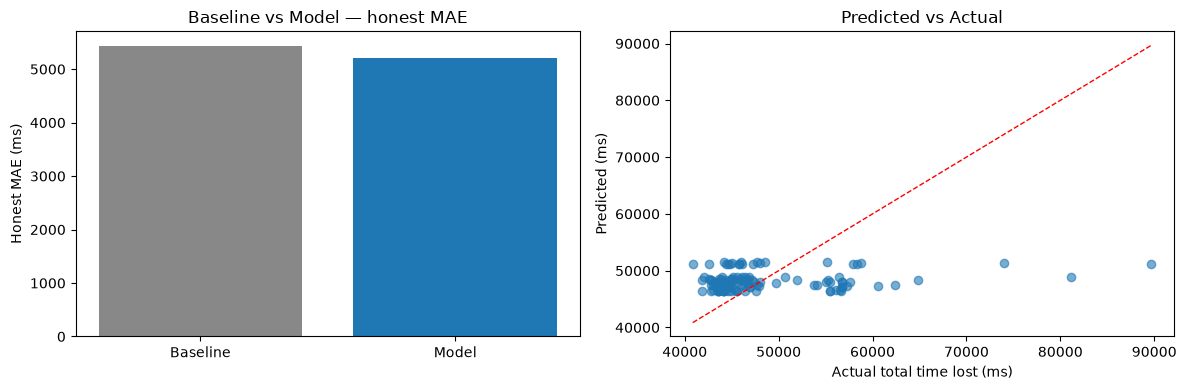

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Baseline", "Model"], [baseline_mae, model_mae], color=["#888", "#1f77b4"])
axes[0].set_ylabel("Honest MAE (ms)")
axes[0].set_title("Baseline vs Model — honest MAE")

axes[1].scatter(y_val, model_pred, alpha=0.6)
lims = [min(y_val.min(), model_pred.min()), max(y_val.max(), model_pred.max())]
axes[1].plot(lims, lims, "r--", linewidth=1)
axes[1].set_xlabel("Actual total time lost (ms)")
axes[1].set_ylabel("Predicted (ms)")
axes[1].set_title("Predicted vs Actual")

plt.tight_layout()
plt.show()

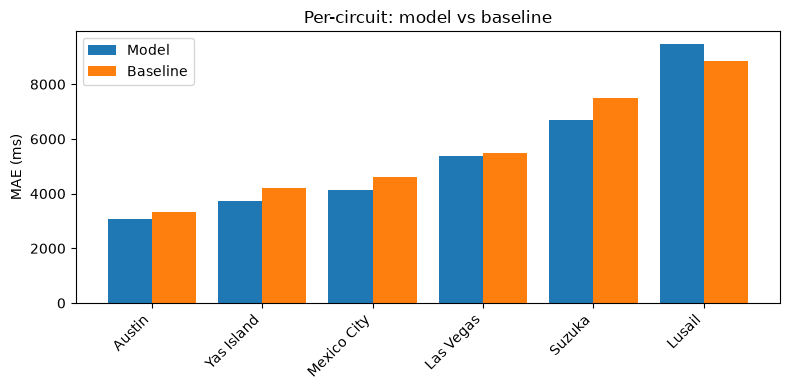

In [16]:
per_circuit_sorted = per_circuit.sort_values("model_mae")
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(per_circuit_sorted))
ax.bar([i - 0.2 for i in x], per_circuit_sorted["model_mae"], width=0.4, label="Model")
ax.bar([i + 0.2 for i in x], per_circuit_sorted["baseline_mae"], width=0.4, label="Baseline")
ax.set_xticks(list(x))
ax.set_xticklabels(per_circuit_sorted.index, rotation=45, ha="right")
ax.set_ylabel("MAE (ms)")
ax.set_title("Per-circuit: model vs baseline")
ax.legend()
plt.tight_layout()
plt.show()